# What drives high Alberta pool prices, and can public AESO data flag them one hour ahead?

Data: AESO *Hourly Metered Volumes and Pool Price and AIL, 2020 – Jul 2025* (analysis uses only Jan 2024 – Jul 2025).

## 0. Imports and settings

In [2]:
import os
import re
import pandas as pd
import requests
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

DATA_PATH = r"PUT_LOCAL_FILE_PATH_HERE" # AESO CSV file from README.md
CSD_URL = "http://ets.aeso.ca/ets_web/ip/Market/Reports/CSDReportServlet" # Current Supply and Demand webpage on AESO website

os.makedirs("figs", exist_ok=True)

## 1. Load data and set a daylight-saving-safe time index

In [3]:
df = pd.read_csv(DATA_PATH)

# Index on GMT (no DST jumps), then convert to Alberta local time
df["time"] = (pd.to_datetime(df["Date_Begin_GMT"])
                .dt.tz_localize("UTC")
                .dt.tz_convert("America/Edmonton"))
df = df.set_index("time").sort_index()
df = df.loc["2024-01-01":]

print(df.shape, df.index.min(), df.index.max())

(13871, 236) 2024-01-01 00:00:00-07:00 2025-07-31 23:00:00-06:00


C:\Users\jayan\AppData\Local\Temp\ipykernel_57028\3064630271.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["time"] = (pd.to_datetime(df["Date_Begin_GMT"])


## 2. Map each generator to a fuel type (from AESO's Current Supply & Demand page)

In [4]:
market_cols = ["ACTUAL_POOL_PRICE", "ACTUAL_AIL", "HOUR_AHEAD_POOL_PRICE_FORECAST",
               "EXPORT_BC", "EXPORT_MT", "EXPORT_SK", "IMPORT_BC", "IMPORT_MT", "IMPORT_SK"]
gen_cols = [c for c in df.columns if c not in market_cols + ["Date_Begin_GMT", "Date_Begin_Local"]]
#print(len(gen_cols))

text = re.sub(r"<[^>]+>", " ", requests.get(CSD_URL, timeout=30).text) # remove HTML tags from CSD webpage text

# Walk through the page: remember the last fuel heading, label each asset ID with it
headers = r"COGENERATION|COMBINED CYCLE|SIMPLE CYCLE|GAS FIRED STEAM|HYDRO|WIND|SOLAR|ENERGY STORAGE|BIOMASS AND OTHER"
fuel_map, current = {}, None
for m in re.finditer(rf"\b({headers})\b|\(([A-Z0-9]{{2,6}})\)", text, flags=re.I):
    if m.group(1):
        current = m.group(1).upper()
    elif m.group(2) and m.group(2).upper() in gen_cols:
        fuel_map[m.group(2).upper()] = current

fuel = pd.Series(fuel_map)
#print(fuel.value_counts())

# Assets not on today's page (mostly retired units) -> reported in README
unmapped = [c for c in gen_cols if c not in fuel_map]
print(len(unmapped), "unmapped assets:", unmapped)
print(f"Unmapped share of generation: {df[unmapped].sum().sum() / df[gen_cols].sum().sum():.2%}")

# Collapse gas subtypes into one GAS category
gas_types = ["COGENERATION", "COMBINED CYCLE", "SIMPLE CYCLE", "GAS FIRED STEAM", "DUAL FUEL"]
fuel = fuel.replace({g: "GAS" for g in gas_types})

10 unmapped assets: ['CRW1', 'GN1', 'GN2', 'KH1', 'NPC1', 'PW01', 'SD3', 'SD4', 'SD5', 'HSM1']
Unmapped share of generation: 1.73%


## 3. Build the clean hourly dataframe

In [5]:
# Sum generator columns into one column per fuel
gen = pd.DataFrame(index=df.index)
for f in fuel.unique():
    ids = fuel[fuel == f].index          # asset IDs with this fuel
    gen[f] = df[ids].sum(axis=1)         # sum those columns hour by hour
gen["UNMAPPED"] = df[unmapped].sum(axis=1)
#print(gen.sum().sort_values(ascending=False))   # sanity check on fuel mix

clean = df[market_cols].join(gen)
clean.columns = clean.columns.str.lower().str.replace(" ", "_")
clean = clean.rename(columns={"actual_pool_price": "price",
                              "actual_ail": "ail",
                              "hour_ahead_pool_price_forecast": "aeso_fcst"})
clean["imports"] = clean[["import_bc", "import_mt", "import_sk"]].sum(axis=1)
clean["exports"] = clean[["export_bc", "export_mt", "export_sk"]].sum(axis=1)

clean.to_csv("clean_hourly.csv")
#print(clean.columns.tolist())
#print(clean.isna().sum())

print(clean.shape)
clean.head()

(13871, 18)


,price,ail,aeso_fcst,export_bc,export_mt,export_sk,import_bc,import_mt,import_sk,gas,hydro,energy_storage,solar,wind,biomass_and_other,unmapped,imports,exports
time,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00-07:00,23.05,9809,20.57,935,0,0,0,35,0,3925.916678,92.186771,0.0,0.0,2844.075540,74.1604,810.20662,35,935
2024-01-01 01:00:00-07:00,22.67,9702,19.69,935,0,0,0,0,0,3890.183935,78.223537,0.0,0.0,2856.859774,75.4038,807.82496,0,935
2024-01-01 02:00:00-07:00,24.07,9560,21.46,935,0,0,0,0,0,4039.820175,105.388039,0.0,0.0,2478.648488,75.4833,810.25408,0,935
2024-01-01 03:00:00-07:00,24.33,9547,24.21,935,0,0,0,40,0,4160.217728,80.026861,0.0,0.0,2354.202080,78.2774,812.03188,40,935
2024-01-01 04:00:00-07:00,24.70,9511,24.48,935,0,0,0,40,0,4270.623296,89.104752,0.0,0.0,2241.476839,77.4373,812.68734,40,935


## 4. Features and target

In [6]:
feat = clean.copy()

# 1. Net load: demand that wind and solar don't cover, left for gas, hydro, and imports
feat["net_load"] = feat["ail"] - feat["wind"] - feat["solar"]

# 2. Target: is this a high-price hour?
#    Threshold = 90th percentile of 2024 prices (training year only, to avoid leakage)
thresh = feat.loc[:"2024-12-31", "price"].quantile(0.90)
feat["high"] = (feat["price"] >= thresh).astype(int)

# 3. Lagged features: last hour's values, which are known when forecasting this hour
for c in ["price", "ail", "wind", "solar", "net_load"]:
    feat[f"{c}_lag1"] = feat[c].shift(1)

# 4. Momentum: is net load rising or falling?
feat["net_load_chg"] = feat["net_load"].shift(1) - feat["net_load"].shift(2)

# 5. Recent stress: highest price in the past 24 hours
feat["price_max24"] = feat["price"].shift(1).rolling(24).max()

# 6. Calendar: always known in advance
feat["hour"] = feat.index.hour
feat["dow"] = feat.index.dayofweek      # 0 = Monday
feat["month"] = feat.index.month

feat = feat.dropna()

print(f"High-price threshold: ${thresh:.2f}/MWh")
print(feat.shape, "| share of high-price hours:", round(feat["high"].mean(), 3))

High-price threshold: $112.22/MWh
(13847, 30) | share of high-price hours: 0.077


## 5. What's different about high-price hours?

In [7]:
print("Share of high-price hours by year:")
display(feat.groupby(feat.index.year)["high"].mean().round(3))

print("Average conditions: normal (0) vs. high-price (1) hours")
display(feat.groupby("high")[["price", "net_load", "ail", "wind", "solar",
                              "gas", "imports", "exports"]].mean().round(0))

Share of high-price hours by year:


time
2024    0.100
2025    0.036
Name: high, dtype: float64

Average conditions: normal (0) vs. high-price (1) hours


,price,net_load,ail,wind,solar,gas,imports,exports
high,,,,,,,,
0,30.0,8125.0,10095.0,1590.0,381.0,5402.0,92.0,405.0
1,347.0,9970.0,10672.0,464.0,238.0,6355.0,307.0,96.0


## 6. Graphs

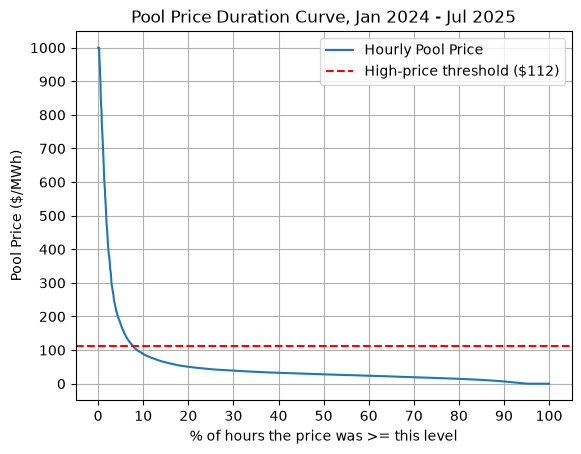

In [8]:
# Figure 1 - Price duration curve
prices = feat["price"].sort_values(ascending=False).reset_index(drop=True)
price_pct = (prices.index + 1) / len(prices) * 100

plt.figure()
plt.plot(price_pct, prices, label="Hourly Pool Price")
plt.axhline(thresh, color="r", ls="--", label=f"High-price threshold (${thresh:.0f})")
plt.xlabel("% of hours the price was >= this level")
plt.ylabel("Pool Price ($/MWh)")
plt.xticks(range(0, 101, 10))
plt.yticks(range(0, 1001, 100))
plt.title("Pool Price Duration Curve, Jan 2024 - Jul 2025")
plt.legend()
plt.grid()
plt.savefig("figs/01_priceduration.png", dpi=150, bbox_inches="tight")
plt.show()

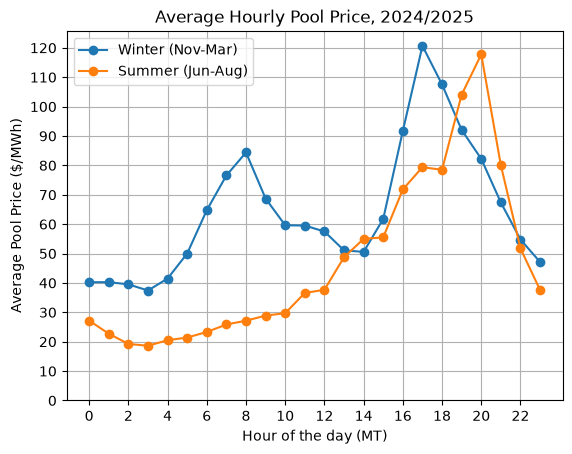

In [7]:
# Figure 2 - Average hourly pool price by season
def get_season(m):
    if m in [11, 12, 1, 2, 3]:
        return "Winter (Nov-Mar)"
    elif m in [6, 7, 8]:
        return "Summer (Jun-Aug)"
    else:
        return None

season = feat["month"].map(get_season)
plt.figure()
for s in ["Winter (Nov-Mar)", "Summer (Jun-Aug)"]:
    feat[season == s].groupby("hour")["price"].mean().plot(label=s, marker="o")
plt.xlabel("Hour of the day (MT)")
plt.ylabel("Average Pool Price ($/MWh)")
plt.xticks(range(0, 24, 2))
plt.yticks(range(0, 130, 10))
plt.title("Average Hourly Pool Price, 2024/2025")
plt.legend()
plt.grid()
plt.savefig("figs/02_avghourlyprice.png", dpi=150, bbox_inches="tight")
plt.show()

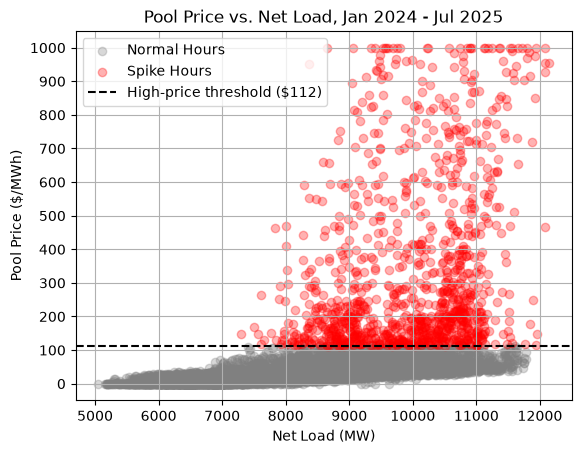

In [10]:
# Figure 3 - Price vs. net load
normal_price = feat[feat["high"] == 0]
spike_price = feat[feat["high"] == 1]

plt.figure()
plt.scatter(normal_price["net_load"], normal_price["price"], alpha=0.3, color="grey", label="Normal Hours")
plt.scatter(spike_price["net_load"], spike_price["price"], alpha=0.3, color="r", label="Spike Hours")
plt.axhline(thresh, color="black", ls="--", label=f"High-price threshold (${thresh:.0f})")
plt.xlabel("Net Load (MW)")
plt.ylabel("Pool Price ($/MWh)")
plt.yticks(range(0, 1001, 100))
plt.title("Pool Price vs. Net Load, Jan 2024 - Jul 2025")
plt.legend()
plt.grid()
plt.savefig("figs/03_price_v_netload.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. One-hour-ahead Model vs. Benchmarks (train 2024, test Jan–Jul 2025)

In [9]:
feats = ["price_lag1", "net_load_lag1", "wind_lag1", "hour"]

train = feat.loc[:"2024-12-31"]
test = feat.loc["2025-01-01":]

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(train[feats], train["high"])        # learn from 2024
prediction = model.predict(test[feats])       # predict 2025

# Baselines: simple rules, no training
persist = (test["price_lag1"] >= thresh).astype(int)   # last hour was high -> predict high
aeso = (test["aeso_fcst"] >= thresh).astype(int)       # AESO's own hour-ahead forecast

print("MY MODEL")
print(classification_report(test["high"], prediction))
print(confusion_matrix(test["high"], prediction))
print("PERSISTENCE")
print(classification_report(test["high"], persist))
print("AESO FORECAST")
print(classification_report(test["high"], aeso))

MY MODEL
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      4905
           1       0.34      0.80      0.48       182

    accuracy                           0.94      5087
   macro avg       0.67      0.87      0.72      5087
weighted avg       0.97      0.94      0.95      5087

[[4625  280]
 [  36  146]]
PERSISTENCE
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4905
           1       0.58      0.58      0.58       182

    accuracy                           0.97      5087
   macro avg       0.78      0.78      0.78      5087
weighted avg       0.97      0.97      0.97      5087

AESO FORECAST
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4905
           1       0.64      0.82      0.72       182

    accuracy                           0.98      5087
   macro avg       0.82      0.90      0.85      5087
weighted avg

               Precision  Recall
Persistence         0.58    0.58
AESO forecast       0.64    0.82
My model            0.34    0.80


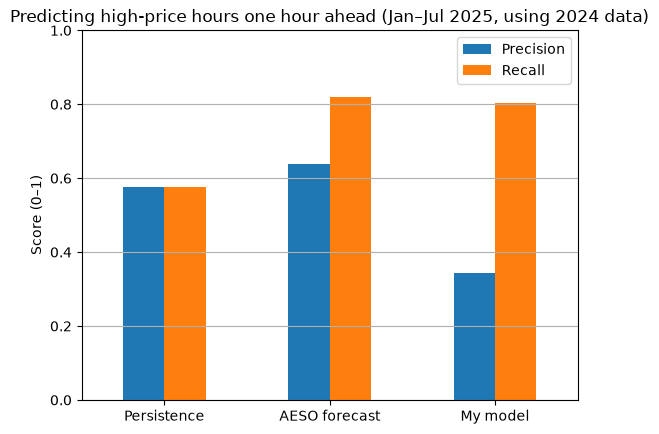

In [11]:
# Figure 4 - Model comparison
methods = {"Persistence": persist, "AESO forecast": aeso, "My model": prediction}
scores = pd.DataFrame({
    "Precision": [precision_score(test["high"], p) for p in methods.values()],
    "Recall":    [recall_score(test["high"], p) for p in methods.values()], }, index=methods.keys())
print(scores.round(2))

scores.plot(kind="bar", rot=0)
plt.ylabel("Score (0–1)")
plt.title("Predicting high-price hours one hour ahead (Jan–Jul 2025, using 2024 data)")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.savefig("figs/04_model_comparison.png", dpi=150)
plt.show()